In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

##### Preparing the dataset

In [2]:
# Check the data
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df.head()


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [3]:
# Use the columns to predict
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df = df[columns].copy()   
#df.isnull().sum()         
df.describe()  

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


##### EDA

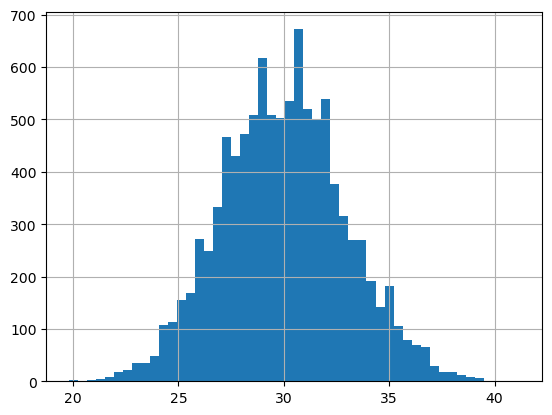

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64
skew: 0.08080419601878173


In [11]:
# Check if this column has a long tail
df['fuel_efficiency_mpg'].hist(bins=50)
plt.show()

print(df['fuel_efficiency_mpg'].describe())
print('skew:', df['fuel_efficiency_mpg'].skew())

# No long tail: the distribution is roughly symmetric and bell-shaped

##### Question 1

In [5]:
# Missing values per column
missing = df.isnull().sum()
print(missing[missing > 0])

horsepower    877
dtype: int64


##### Question 2

In [6]:
# The median for the variable 'horsepower'
median_hp = df['horsepower'].median()
print(f"The median for column 'horsepower' is {median_hp}")

The median for column 'horsepower' is 254.0


##### Prepare and split the data

In [34]:
# Use the total length of the dataframe to create 60/20/20 dataset(s)
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val   = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test  = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

In [35]:
# Get and delete the y-value from the dataframes
y_train = df_train['fuel_efficiency_mpg'].values
y_val   = df_val['fuel_efficiency_mpg'].values
y_test  = df_test['fuel_efficiency_mpg'].values

for d in (df_train, df_val, df_test):
    del d['fuel_efficiency_mpg']

##### Question 3

In [36]:
# Calculate the mean of the variable 'horsepower' from the df_train dataset
mean_hp = df_train['horsepower'].mean()

# Create a function to fill the missing values
def fill_na(df, value):
    df = df.copy()
    df['horsepower'] = df['horsepower'].fillna(value)

    return df.values

In [37]:
# Run linear regression, with optional regularization (r=0 means none)
# Formula > y = w0·1 + w1·x1 + w2·x2 + ...
def linear_regression(X, y, r=0): # add the regularization term for question 4
    ones = np.ones(X.shape[0]) 
    X = np.column_stack([ones, X])

    # Calculate the coefficient vector
    X_T = X.T # or X.transpose()
    X_T_X = X_T @ X
    X_T_X = X_T_X + r * np.eye(X_T_X.shape[0]) # where np.eye creates the identity matrix to calculate this on the diagonal
    XTX_inv = np.linalg.inv(X_T_X)

    w = XTX_inv @ X_T @ y

    # Return the intercept w[0] and an array of the weight per feature
    return w[0], w[1:]

In [38]:
# Calculate the RMSE > Root Mean Squared Error
def rmse(y, y_hat):
    error = (y - y_hat) ** 2
    mean_error = error.mean()
    
    return np.sqrt(mean_error)

In [39]:
# Calculate the RMSE to check which fill_na is the lowest
for name, fill in [('zero', 0), ('mean', mean_hp)]:
    X_train = fill_na(df_train, fill)
    X_val = fill_na(df_val, fill)

    w0, w = linear_regression(X_train, y_train) # calculate the weights on the training dataset
    y_pred = w0 + X_val @ w # predict on the validation dataset

    print(f"{name}: {round(rmse(y_val, y_pred), 3)}")

zero: 2.205
mean: 2.202


##### Question 4

In [40]:
# Calculate the RMSE to check which regularization term is the lowest
X_train = fill_na(df_train, 0)
X_val = fill_na(df_val, 0)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = linear_regression(X_train, y_train, r) # calculate the weights on the training dataset
    y_pred = w0 + X_val @ w # predict on the validation dataset

    print(f"{r}: {round(rmse(y_val, y_pred), 4)}")

# Best RMSE at r = 0 (2.2053), where the RMSE only gets worse as r grows

0: 2.2053
0.01: 2.2058
0.1: 2.2241
1: 2.3492
5: 2.4094
10: 2.4195
100: 2.4292


##### Question 5

In [ ]:
# Use every seed in the range to 10
results = []

for seed in range(10):
    # Use the total length of the dataframe to create 60/20/20 dataset(s) for every seed
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True) # reset_index gives a real copy, so del in the for-loop won't touch the original df
    df_val   = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test  = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val   = df_val['fuel_efficiency_mpg'].values
    y_test  = df_test['fuel_efficiency_mpg'].values

    for d in (df_train, df_val, df_test):
        del d['fuel_efficiency_mpg']

    # Calculate the prediction with fill_na 0 and without regularization
    X_train = fill_na(df_train, 0)
    X_val = fill_na(df_val, 0)

    w0, w = linear_regression(X_train, y_train) 
    y_pred = w0 + X_val @ w 

    # Calculate the RMSE and append this to the list
    result = rmse(y_val, y_pred)
    results.append(result)
    print(f"{seed}: {round(result, 3)}")

# Calculate the standard deviation on the entire list
print(f"std: {round(np.std(results), 3)}")

0: 2.239
1: 2.202
2: 2.163
3: 2.204
4: 2.202
5: 2.246
6: 2.27
7: 2.191
8: 2.217
9: 2.207
std: 0.029


##### Question 6

In [ ]:
# Use the total length of the dataframe to create 60/20/20 dataset(s) with seed 9
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val   = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test  = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val   = df_val['fuel_efficiency_mpg'].values
y_test  = df_test['fuel_efficiency_mpg'].values

for d in (df_train, df_val, df_test):
    del d['fuel_efficiency_mpg']